In [2]:
#importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('default')

In [3]:
# loading datasets
sentiment = pd.read_csv('data/fear_greed_index.csv')
#trade = pd.read_csv('data/historical_data.csv')

In [ ]:
# making require changes so data remains constant
trade['Trade ID'] = trade['Trade ID'].astype(str)
trade['Order ID'] = trade['Order ID'].astype(str)
sentiment['sentiment']=sentiment['classification'].str.lower()
sentiment['datetime']= pd.to_datetime(sentiment['timestamp'],unit='s')
trade['datetime']= pd.to_datetime(trade['Timestamp'],unit='ms')
sentiment['Date']= sentiment['datetime'].dt.normalize()
trade['Date']= trade['datetime'].dt.normalize()

In [ ]:
# merging both datasets with help of date
union= trade.merge(sentiment[['Date','sentiment']],on='Date',how='left')

In [ ]:
#dropping columns
union.drop(columns=['Timestamp IST','Timestamp'],inplace=True)
union.dropna(subset=['sentiment'],inplace=True)
union.columns=union.columns.str.lower().str.replace(' ','_').str.strip()

In [ ]:
# making calculations
union['is_profitable']=union['closed_pnl']>0
all_sentiments = ['extreme fear','fear','neutral','greed','extreme greed']
union['sentiment']=pd.Categorical(union['sentiment'],categories=all_sentiments ,ordered=True)

In [ ]:
#creating dataframes
avg_pnl=union.groupby('sentiment')['closed_pnl'].mean().reindex(all_sentiments)
avg_pnl_df=avg_pnl.reset_index(name='avg_pnl')
avg_pnl_df.to_csv('avg_profit_or_loss_by_sentiment.csv',index=False)

/tmp/ipython-input-79977184.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_pnl=union.groupby('sentiment')['closed_pnl'].mean().reindex(all_sentiments)


In [ ]:
profit_rate=union.groupby("sentiment")["is_profitable"].mean()*100
profit_rate_df=profit_rate.reset_index(name='win_rate_percent')
profit_rate_df.to_csv('win_rate_by_sentiment.csv',index=False)

/tmp/ipython-input-1053101315.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  profit_rate=union.groupby("sentiment")["is_profitable"].mean()*100


In [ ]:
# dividing transactions into 4 types based on trade size
union=union.dropna(subset=['size_usd'])
union['size_category']=pd.qcut(union['size_usd'],q=4,labels=["small","medium","large","very large"],duplicates="drop")
size_profit=union.groupby(["sentiment","size_category"],observed=True)["closed_pnl"].mean().reset_index()

In [ ]:
size_sentiment_avg = (union.groupby(['sentiment', 'size_category'])['closed_pnl'].mean().reset_index())
win_rate_by_size = (union.groupby('size_category')['is_profitable'].mean().mul(100).reset_index(name='win_rate_percent'))
win_rate_size_sentiment = (union.groupby(['sentiment', 'size_category'])['is_profitable'].mean().mul(100).reset_index(name='win_rate_percent'))

/tmp/ipython-input-1209096850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_sentiment_avg = (union.groupby(['sentiment', 'size_category'])['closed_pnl'].mean().reset_index())
/tmp/ipython-input-1209096850.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate_by_size = (union.groupby('size_category')['is_profitable'].mean().mul(100).reset_index(name='win_rate_percent'))
/tmp/ipython-input-1209096850.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt

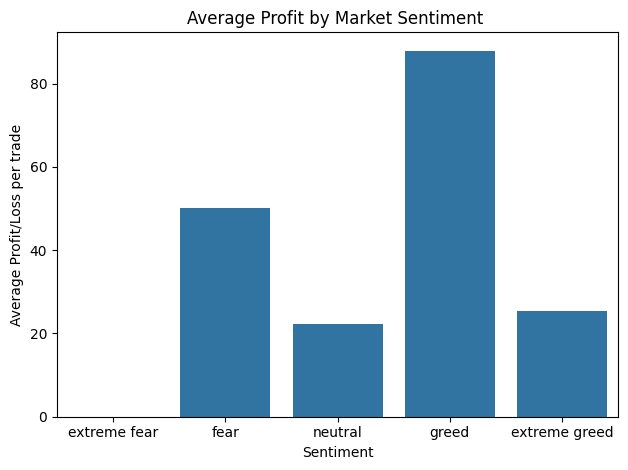

In [ ]:
sns.barplot(
    data=avg_pnl_df,
    x='sentiment',
    y= 'avg_pnl',
    order=all_sentiments
)
plt.title('Average Profit by Market Sentiment ')
plt.xlabel('Sentiment')
plt.ylabel('Average Profit/Loss per trade')
plt.tight_layout()
plt.show()


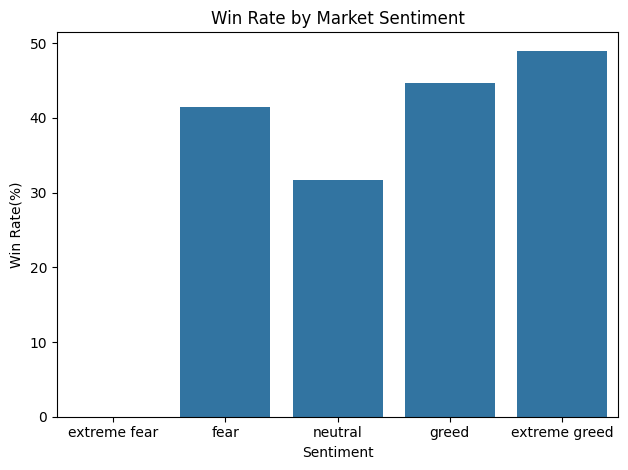

In [ ]:

sns.barplot(
    data=profit_rate_df,
    x='sentiment',
    y='win_rate_percent',
    order=all_sentiments
)
plt.title('Win Rate by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Win Rate(%)')
plt.tight_layout()
plt.show()

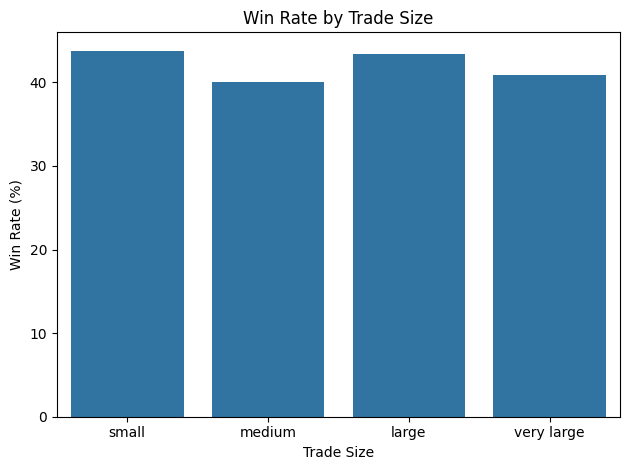

In [ ]:
sns.barplot(
    data=win_rate_by_size,
    x='size_category',
    y='win_rate_percent',
    order=["small", "medium", "large", "very large"],
    errorbar=None
)
plt.title('Win Rate by Trade Size')
plt.xlabel('Trade Size')
plt.ylabel('Win Rate (%)')
plt.tight_layout()
plt.show()

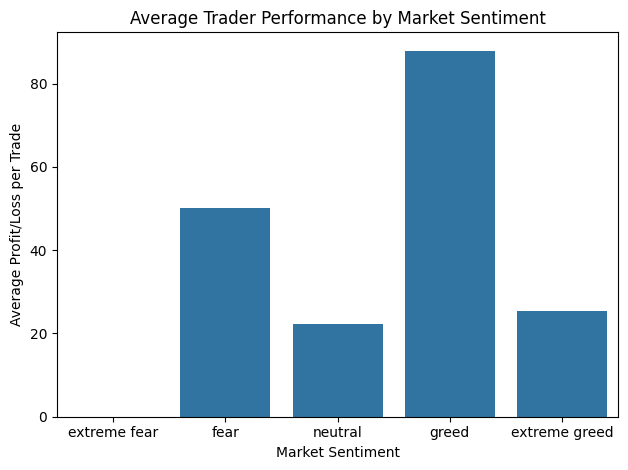

In [ ]:
sns.barplot(
    data=avg_pnl_df,
    x='sentiment',
    y='avg_pnl',
    order=all_sentiments
)
plt.title('Average Trader Performance by Market Sentiment')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Profit/Loss per Trade')
plt.tight_layout()
plt.show()

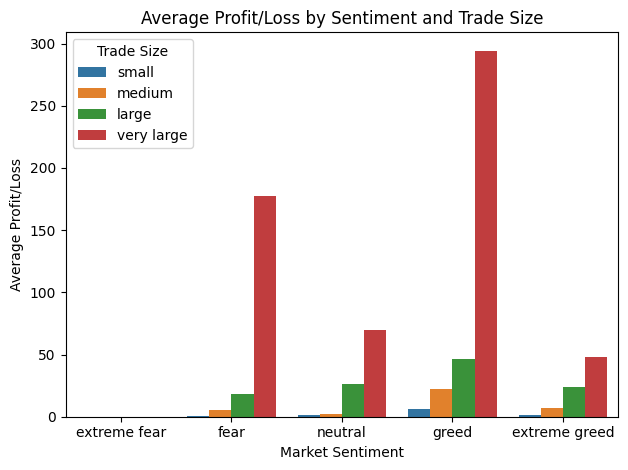

In [ ]:
sns.barplot(
    data=size_sentiment_avg,
    x='sentiment',
    y='closed_pnl',
    hue='size_category',
    order=all_sentiments
)
plt.title('Average Profit/Loss by Sentiment and Trade Size')
plt.xlabel('Market Sentiment')
plt.ylabel('Average Profit/Loss')
plt.legend(title='Trade Size')
plt.tight_layout()
plt.show()


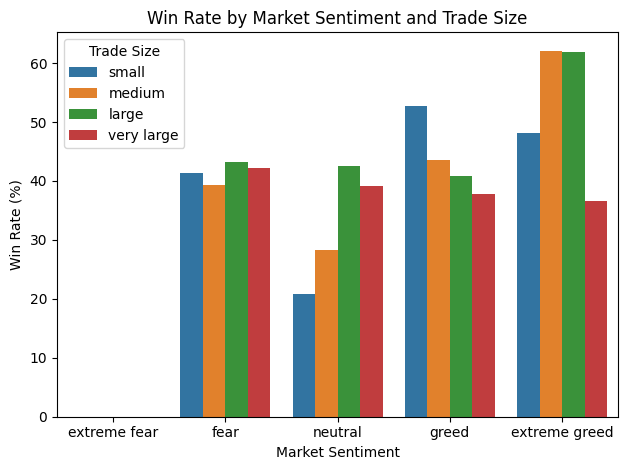

In [ ]:
sns.barplot(
    data=win_rate_size_sentiment,
    x='sentiment',
    y='win_rate_percent',
    hue='size_category',
    order=all_sentiments,
    errorbar=None
)
plt.title('Win Rate by Market Sentiment and Trade Size')
plt.xlabel('Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.legend(title='Trade Size')
plt.tight_layout()
plt.show()


In [ ]:
trader_performance=union.groupby(['account','sentiment'])['closed_pnl'].sum().reset_index()
trader_performance.to_csv("trader_performance.csv",index=False)

union.to_csv('Final_Output.csv',index=False)

/tmp/ipython-input-2460005719.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trader_performance=union.groupby(['account','sentiment'])['closed_pnl'].sum().reset_index()
